## Module 4: Model with Results

Group: 3

Vaishnavi Govind Bhamare - 11829714

Ujwal Kumar Bhukya - 11828494

Kinjalben Savaliya – 11805512

Research Question: Can we predict whether a flight’s arrival time will change after departure using operational and airport-related features?

Importing the necessary libraries

In [ ]:
import pandas as pd
import numpy as np

Loaded the flight data and checked if the data set has been loaded correctly.

In [ ]:
# Loading the Flight data
df_flight = pd.read_csv(
    "Capstone Project Data Set 2.csv",
    encoding="latin1",
    engine="python",
    on_bad_lines="skip"
)

print("Flight data shape:", df_flight.shape)
df_flight.head()

Flight data shape: (1048575, 64)


,FLIGHT_HUB_EVENT_TYPE_CD,OPERAT_AIRLN_IATA_CD,OPERAT_FLIGHT_NBR,SCHD_LEG_DEP_AIRPRT_IATA_CD,SCHD_LEG_ARVL_AIRPRT_IATA_CD,ACTL_LEG_DEP_AIRPRT_IATA_CD,ACTL_LEG_ARVL_AIRPRT_IATA_CD,ETD_LCL_TMS,PREV_ETD_LCL_TMS,SCHD_FIRST_LEG_DEP_LCL_DT,...,SUBSEQUENT_LEG_OF_DIVERT_IND,LNIATA_TXT,PRSNEL_ID,FOS_AGENT_SINE_HOME_CITY_CD,FOS_AGENT_SINE_CD,USER_AUDIT_TMS,ACTN_CD,FLIGHT_TYPE_CD,MULTI_OPS_IND,SF_LOAD_TMS
0,CYCLE,OO,4965.0,DFW,GCK,DFW,GCK,54:00.0,NaN,19-03-2023,...,N,NaN,NaN,NaN,NaN,NaN,NaN,C,N,50:13.9
1,CYCLE,OO,6486.0,DFW,AEX,DFW,AEX,45:00.0,NaN,15-03-2025,...,N,NaN,NaN,NaN,NaN,NaN,NaN,C,N,50:13.9
2,CYCLE,OO,4931.0,DFW,LBB,DFW,LBB,41:00.0,NaN,09-10-2024,...,N,NaN,NaN,NaN,NaN,NaN,NaN,C,N,50:13.9
3,CYCLE,OO,6275.0,DFW,DRO,DFW,DRO,28:00.0,NaN,03-08-2024,...,N,NaN,NaN,NaN,NaN,NaN,NaN,C,N,50:13.9
4,ETD,YV,5871.0,DFW,GPT,DFW,GPT,55:00.0,50:00.0,25-07-2022,...,N,8B7667,729207.0,PIT,AAA,25:39.5,PRX,C,N,50:13.9


Checked the columns in the flight data.

In [ ]:
# Check the columns
print("Flight columns:")
for col in df_flight.columns:
    print(col)

Flight columns:
FLIGHT_HUB_EVENT_TYPE_CD
OPERAT_AIRLN_IATA_CD
OPERAT_FLIGHT_NBR
SCHD_LEG_DEP_AIRPRT_IATA_CD
SCHD_LEG_ARVL_AIRPRT_IATA_CD
ACTL_LEG_DEP_AIRPRT_IATA_CD
ACTL_LEG_ARVL_AIRPRT_IATA_CD
ETD_LCL_TMS
PREV_ETD_LCL_TMS
SCHD_FIRST_LEG_DEP_LCL_DT
SCHD_LEG_DEP_LCL_DT
SCHD_LEG_DEP_LCL_TM
SCHD_LEG_DEP_LCL_TMS
SCHD_LEG_ARVL_LCL_DT
SCHD_LEG_ARVL_LCL_TM
SCHD_LEG_ARVL_LCL_TMS
SCHD_LEG_DEP_GMT_TMS
SCHD_LEG_ARVL_GMT_TMS
ACTL_LEG_DEP_LCL_DT
ACTL_LEG_DEP_LCL_TM
ACTL_LEG_ARVL_LCL_DT
ACTL_LEG_ARVL_LCL_TM
ACTL_LEG_DEP_LCL_TMS
ACTL_LEG_ARVL_LCL_TMS
ACTL_LEG_DEP_GMT_TMS
ACTL_LEG_ARVL_GMT_TMS
LEG_DEP_VARNCE_MIN_QTY
LEG_ARVL_VARNCE_MIN_QTY
LEG_BLOCK_VARNCE_MIN_QTY
RS_IND
ACTL_LEG_DEP_GATE_CD
ACTL_LEG_ARVL_GATE_CD
ACTL_AIRCFT_TAIL_CD
SCHD_FLEET_CD
SCHD_SUBFLEET_CD
ACTL_FLEET_CD
ACTL_SUBFLEET_CD
DEP_AIRPRT_ENROUT_REGION_CD
ARVL_AIRPRT_ENROUT_REGION_CD
DFW_POST_TMS
ORIGIN_POST_TMS
EFF_GMT_TMS
EXP_GMT_TMS
MINS_TO_SCHD_DEP_QTY
POST_NBR
TTL_POST_QTY
POST_FINAL_IND
DEP_STATUS_DESC
ARVL_STATUS_DESC
FLIFO_DELA

Loaded the airport data and checked if the data has been loaded correctly.

In [ ]:
# Load the airport data
df_airport = pd.read_excel("Capstone Project Data set.xlsx")

print("Airport data shape:", df_airport.shape)
df_airport.head()

Airport data shape: (4565, 17)


,AIRPRT_CD,AIRPRT_NM,CITY_METRO_IATA_CD,STATE_PROVNC_CD,CNTRY_CD,WRLD_AREA_DOT_CD,LAT_DEGREE_QTY,LAT_MINUTE_QTY,LAT_SECOND_QTY,LAT_HEMSPHR_CD,LNGTD_DEGREE_QTY,LNGTD_MINUTE_QTY,LNGTD_SECOND_QTY,LNGTD_HEMSPHR_CD,LNGST_RUNWAY_FT_QTY,ELEVATN_FT_QTY,SF_LOAD_TMS
0,OAH,Shindand Air Base,OAH,NaN,AF,701,33,23,32,N,62,15,40,E,7900,3780,2025-02-17 16:55:48.934
1,REX,Lucio Blanco Intl,REX,NaN,MX,148,26,0,30,N,98,13,41,W,6200,139,2025-02-17 16:55:48.934
2,YQX,Gander Intl.,YQX,NL,CA,961,48,56,13,N,54,34,5,W,10200,496,2025-02-17 16:55:48.934
3,MLW,Spriggs Payne,MLW,NaN,LR,537,6,17,19,N,10,45,32,W,6000,26,2025-02-17 16:55:48.934
4,CIJ,Capitan Anibal Arab,CIJ,NaN,BO,312,11,2,16,S,68,47,0,W,8500,805,2025-02-17 16:55:48.934


Only kept the needed column from airport data i.e airport code, runway length and elevation.

In [ ]:
# Keeping only the needed column
df_airport_small = df_airport[
    ["AIRPRT_CD", "LNGST_RUNWAY_FT_QTY", "ELEVATN_FT_QTY"]
].copy()

df_airport_small = df_airport_small.rename(columns={
    "AIRPRT_CD": "airport_code",
    "LNGST_RUNWAY_FT_QTY": "runway_length",
    "ELEVATN_FT_QTY": "elevation"
})

print("Airport cleaned shape:", df_airport_small.shape)
df_airport_small.head()

Airport cleaned shape: (4565, 3)


,airport_code,runway_length,elevation
0,OAH,7900,3780
1,REX,6200,139
2,YQX,10200,496
3,MLW,6000,26
4,CIJ,8500,805


I created a unique flight ID to uniquely identify each flight record by combining airline, flight number, date, time, and airport information. This helped ensure there were no duplicate records and made it easier to track and merge data correctly.

Only used for data validation not used in model

In [ ]:
# Creating a flight Id
df_work = df_flight.copy()

df_work["flight_id"] = (
    df_work["OPERAT_AIRLN_IATA_CD"].astype(str) + "_" +
    df_work["OPERAT_FLIGHT_NBR"].astype(str) + "_" +
    df_work["SCHD_LEG_DEP_LCL_DT"].astype(str) + "_" +
    df_work["SCHD_LEG_DEP_LCL_TM"].astype(str) + "_" +
    df_work["SCHD_LEG_DEP_AIRPRT_IATA_CD"].astype(str) + "_" +
    df_work["SCHD_LEG_ARVL_AIRPRT_IATA_CD"].astype(str)
)

print("Unique flight IDs:", df_work["flight_id"].nunique())

Unique flight IDs: 43689


Only kept at and after departure removed before departure to ensure the model uses only post departure and filtered the pre departure records.

In [ ]:
# Keeping only the rows after scheduled Departure
df_post_dep = df_work[df_work["MINS_TO_SCHD_DEP_QTY"].notna()].copy()
df_post_dep = df_post_dep[df_post_dep["MINS_TO_SCHD_DEP_QTY"] <= 0].copy()

print("Post-departure shape:", df_post_dep.shape)

Post-departure shape: (302461, 65)


I selected the first record after departure for each flight to ensure consistency and avoid duplicate observations per flight in the model.

I did this step to avoid data leakage.

In [ ]:
# Selecting the first post after Departure
df_post_dep["abs_gap"] = df_post_dep["MINS_TO_SCHD_DEP_QTY"].abs()

df_post_dep = df_post_dep.sort_values(
    by=["flight_id", "abs_gap", "POST_NBR"],
    ascending=[True, True, True]
)

df_model = df_post_dep.groupby("flight_id").head(1).copy()

print("Modeling shape after first post selection:", df_model.shape)
df_model.head()

Modeling shape after first post selection: (29697, 66)


,FLIGHT_HUB_EVENT_TYPE_CD,OPERAT_AIRLN_IATA_CD,OPERAT_FLIGHT_NBR,SCHD_LEG_DEP_AIRPRT_IATA_CD,SCHD_LEG_ARVL_AIRPRT_IATA_CD,ACTL_LEG_DEP_AIRPRT_IATA_CD,ACTL_LEG_ARVL_AIRPRT_IATA_CD,ETD_LCL_TMS,PREV_ETD_LCL_TMS,SCHD_FIRST_LEG_DEP_LCL_DT,...,PRSNEL_ID,FOS_AGENT_SINE_HOME_CITY_CD,FOS_AGENT_SINE_CD,USER_AUDIT_TMS,ACTN_CD,FLIGHT_TYPE_CD,MULTI_OPS_IND,SF_LOAD_TMS,flight_id,abs_gap
784315,ETD,AA,1001.0,DFW,CUN,DFW,CUN,19:00.0,09:00.0,24-10-2024,...,NaN,NO,AAA,19:20.1,PRX,A,N,50:13.9,AA_1001.0_00:00.0_09:09:00_DFW_CUN,10.0
821402,ETD,AA,1001.0,DFW,CUN,DFW,CUN,05:00.0,50:00.0,24-12-2022,...,729990.0,HDQ,TW1,46:20.8,PRX,A,N,50:13.9,AA_1001.0_00:00.0_09:16:00_DFW_CUN,30.0
835979,ETD,AA,1001.0,DFW,CUN,DFW,CUN,00:00.0,45:00.0,14-05-2024,...,729990.0,HDQ,TW1,20:34.5,PRX,A,N,50:13.9,AA_1001.0_00:00.0_09:20:00_DFW_CUN,0.0
804380,ETD,AA,1001.0,DFW,CUN,DFW,CUN,34:00.0,27:00.0,07-04-2024,...,729990.0,HDQ,TW1,28:07.4,PRX,A,N,50:13.9,AA_1001.0_00:00.0_09:27:00_DFW_CUN,1.0
829951,ETD,AA,1001.0,DFW,CUN,DFW,CUN,45:00.0,30:00.0,10-10-2023,...,729990.0,HDQ,TW1,30:14.3,PRX,A,N,50:13.9,AA_1001.0_00:00.0_09:30:00_DFW_CUN,0.0


As the model cannot run without the correct output value i removed the rows where target was missing.

In [ ]:
# Removing the rows where Target is missing
df_model = df_model.dropna(subset=["LEG_ARVL_VARNCE_MIN_QTY"]).copy()

print("Shape after dropping missing target:", df_model.shape)

Shape after dropping missing target: (29387, 66)


I created two target variables: one for classification (whether arrival changed or not) and one for regression (how much it changed).

In [ ]:
# Creating Target Variables
df_model["arrival_change_flag"] = df_model["LEG_ARVL_VARNCE_MIN_QTY"].apply(
    lambda x: 1 if x != 0 else 0
)

df_model["arrival_variance"] = df_model["LEG_ARVL_VARNCE_MIN_QTY"]

df_model[["arrival_variance", "arrival_change_flag"]].head()

,arrival_variance,arrival_change_flag
784315,23.0,1
821402,51.0,1
835979,114.0,1
804380,18.0,1
829951,14.0,1


I prepared airport data sso i can merge the data.

In [ ]:
# Preparing airport data for merging (One for Departure Airport and One for Arrival Airport)
dep_airport = df_airport_small.rename(columns={
    "airport_code": "SCHD_LEG_DEP_AIRPRT_IATA_CD",
    "runway_length": "dep_runway_length",
    "elevation": "dep_elevation"
})

arr_airport = df_airport_small.rename(columns={
    "airport_code": "SCHD_LEG_ARVL_AIRPRT_IATA_CD",
    "runway_length": "arr_runway_length",
    "elevation": "arr_elevation"
})

I merged airport data with flight data using departure and arrival airport codes to add features like runway length and elevation for both airports.

In [ ]:
# Merging Airport features into flight data
df_model = df_model.merge(dep_airport, on="SCHD_LEG_DEP_AIRPRT_IATA_CD", how="left")
df_model = df_model.merge(arr_airport, on="SCHD_LEG_ARVL_AIRPRT_IATA_CD", how="left")

print("Shape after airport merge:", df_model.shape)
df_model.head()

Shape after airport merge: (29387, 72)


,FLIGHT_HUB_EVENT_TYPE_CD,OPERAT_AIRLN_IATA_CD,OPERAT_FLIGHT_NBR,SCHD_LEG_DEP_AIRPRT_IATA_CD,SCHD_LEG_ARVL_AIRPRT_IATA_CD,ACTL_LEG_DEP_AIRPRT_IATA_CD,ACTL_LEG_ARVL_AIRPRT_IATA_CD,ETD_LCL_TMS,PREV_ETD_LCL_TMS,SCHD_FIRST_LEG_DEP_LCL_DT,...,MULTI_OPS_IND,SF_LOAD_TMS,flight_id,abs_gap,arrival_change_flag,arrival_variance,dep_runway_length,dep_elevation,arr_runway_length,arr_elevation
0,ETD,AA,1001.0,DFW,CUN,DFW,CUN,19:00.0,09:00.0,24-10-2024,...,N,50:13.9,AA_1001.0_00:00.0_09:09:00_DFW_CUN,10.0,1,23.0,13400,606,11400.0,22.0
1,ETD,AA,1001.0,DFW,CUN,DFW,CUN,05:00.0,50:00.0,24-12-2022,...,N,50:13.9,AA_1001.0_00:00.0_09:16:00_DFW_CUN,30.0,1,51.0,13400,606,11400.0,22.0
2,ETD,AA,1001.0,DFW,CUN,DFW,CUN,00:00.0,45:00.0,14-05-2024,...,N,50:13.9,AA_1001.0_00:00.0_09:20:00_DFW_CUN,0.0,1,114.0,13400,606,11400.0,22.0
3,ETD,AA,1001.0,DFW,CUN,DFW,CUN,34:00.0,27:00.0,07-04-2024,...,N,50:13.9,AA_1001.0_00:00.0_09:27:00_DFW_CUN,1.0,1,18.0,13400,606,11400.0,22.0
4,ETD,AA,1001.0,DFW,CUN,DFW,CUN,45:00.0,30:00.0,10-10-2023,...,N,50:13.9,AA_1001.0_00:00.0_09:30:00_DFW_CUN,0.0,1,14.0,13400,606,11400.0,22.0


I selected features based on domain knowledge factors that influence flight delays such as departure delays, timing, airport characteristics, and operational status.

These features tell me when the flight is leaving, how delayed it is, what its status is, and where it is coming from and going to.

In [ ]:
# Feature Selection
features = [
    "LEG_DEP_VARNCE_MIN_QTY",
    "MINS_TO_SCHD_DEP_QTY",
    "DEP_STATUS_DESC",
    "SCHD_LEG_DEP_AIRPRT_IATA_CD",
    "SCHD_LEG_ARVL_AIRPRT_IATA_CD",
    "dep_runway_length",
    "dep_elevation",
    "arr_runway_length",
    "arr_elevation"
]

df_model_features = df_model[features].copy()
df_model_features["arrival_change_flag"] = df_model["arrival_change_flag"]
df_model_features["arrival_variance"] = df_model["arrival_variance"]

print("Selected feature shape:", df_model_features.shape)
df_model_features.head()

Selected feature shape: (29387, 11)


,LEG_DEP_VARNCE_MIN_QTY,MINS_TO_SCHD_DEP_QTY,DEP_STATUS_DESC,SCHD_LEG_DEP_AIRPRT_IATA_CD,SCHD_LEG_ARVL_AIRPRT_IATA_CD,dep_runway_length,dep_elevation,arr_runway_length,arr_elevation,arrival_change_flag,arrival_variance
0,41.0,-10.0,ETD,DFW,CUN,13400,606,11400.0,22.0,1,23.0
1,56.0,-30.0,ETD,DFW,CUN,13400,606,11400.0,22.0,1,51.0
2,86.0,0.0,ETD,DFW,CUN,13400,606,11400.0,22.0,1,114.0
3,16.0,-1.0,ETD,DFW,CUN,13400,606,11400.0,22.0,1,18.0
4,19.0,0.0,ETD,DFW,CUN,13400,606,11400.0,22.0,1,14.0


Dropped the missing values

In [ ]:
# Drop missing value
df_model_features = df_model_features.dropna().copy()

print("Shape after dropping missing values:", df_model_features.shape)
print(df_model_features.isnull().sum())

Shape after dropping missing values: (29383, 11)
LEG_DEP_VARNCE_MIN_QTY          0
MINS_TO_SCHD_DEP_QTY            0
DEP_STATUS_DESC                 0
SCHD_LEG_DEP_AIRPRT_IATA_CD     0
SCHD_LEG_ARVL_AIRPRT_IATA_CD    0
dep_runway_length               0
dep_elevation                   0
arr_runway_length               0
arr_elevation                   0
arrival_change_flag             0
arrival_variance                0
dtype: int64


Converting categorical to numerical

In [ ]:
# Converting categorical variable to numeric
df_model_features = pd.get_dummies(
    df_model_features,
    columns=[
        "DEP_STATUS_DESC",
        "SCHD_LEG_DEP_AIRPRT_IATA_CD",
        "SCHD_LEG_ARVL_AIRPRT_IATA_CD"
    ],
    drop_first=True
)

print("Shape after encoding:", df_model_features.shape)
df_model_features.head()

Shape after encoding: (29383, 279)


,LEG_DEP_VARNCE_MIN_QTY,MINS_TO_SCHD_DEP_QTY,dep_runway_length,dep_elevation,arr_runway_length,arr_elevation,arrival_change_flag,arrival_variance,DEP_STATUS_DESC_ETD,DEP_STATUS_DESC_FLT,...,SCHD_LEG_ARVL_AIRPRT_IATA_CD_XNA,SCHD_LEG_ARVL_AIRPRT_IATA_CD_XPL,SCHD_LEG_ARVL_AIRPRT_IATA_CD_YUL,SCHD_LEG_ARVL_AIRPRT_IATA_CD_YUM,SCHD_LEG_ARVL_AIRPRT_IATA_CD_YVR,SCHD_LEG_ARVL_AIRPRT_IATA_CD_YYC,SCHD_LEG_ARVL_AIRPRT_IATA_CD_YYZ,SCHD_LEG_ARVL_AIRPRT_IATA_CD_ZCL,SCHD_LEG_ARVL_AIRPRT_IATA_CD_ZIH,SCHD_LEG_ARVL_AIRPRT_IATA_CD_ZLO
0,41.0,-10.0,13400,606,11400.0,22.0,1,23.0,True,False,...,False,False,False,False,False,False,False,False,False,False
1,56.0,-30.0,13400,606,11400.0,22.0,1,51.0,True,False,...,False,False,False,False,False,False,False,False,False,False
2,86.0,0.0,13400,606,11400.0,22.0,1,114.0,True,False,...,False,False,False,False,False,False,False,False,False,False
3,16.0,-1.0,13400,606,11400.0,22.0,1,18.0,True,False,...,False,False,False,False,False,False,False,False,False,False
4,19.0,0.0,13400,606,11400.0,22.0,1,14.0,True,False,...,False,False,False,False,False,False,False,False,False,False


I created a correlation matrix to understand how different features are related to each other and to the target variable.

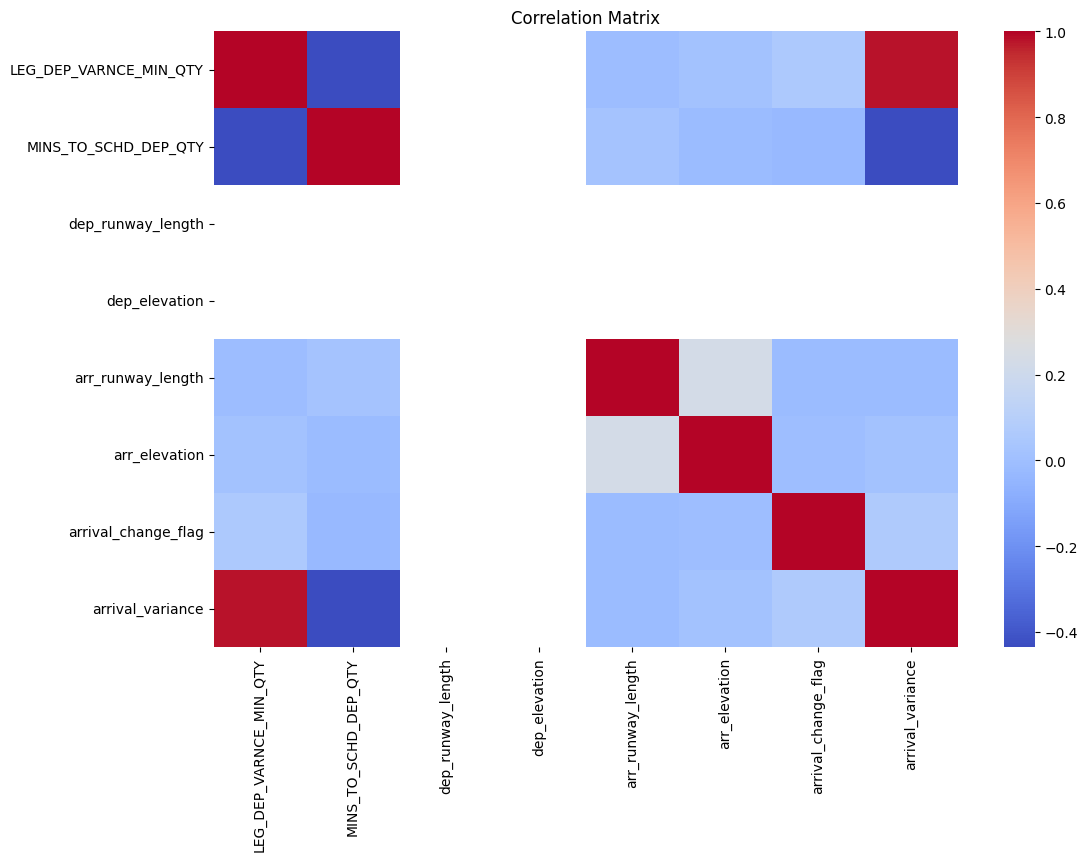

In [ ]:
# Create a correlation matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
df_corr = df_model_features.select_dtypes(include=["int64", "float64"])

# Compute correlation
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

I computed correlation of each feature with the target to identify which variables influence arrival changes the most.

In [ ]:
corr_target = corr_matrix["arrival_change_flag"].sort_values(ascending=False)

print("Correlation with target:\n")
print(corr_target)

Correlation with target:

arrival_change_flag       1.000000
arrival_variance          0.065445
LEG_DEP_VARNCE_MIN_QTY    0.056360
arr_elevation            -0.008161
arr_runway_length        -0.016257
MINS_TO_SCHD_DEP_QTY     -0.030838
dep_runway_length              NaN
dep_elevation                  NaN
Name: arrival_change_flag, dtype: float64


In [ ]:
# Split data into X and y
X = df_model_features.drop(columns=["arrival_change_flag", "arrival_variance"])
y = df_model_features["arrival_change_flag"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (29383, 277)
y shape: (29383,)


In [ ]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (23506, 277)
Test shape: (5877, 277)


In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, class_weight="balanced")
model_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# Logistic Regression Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))
print("\nLogistic Regression Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))
print("\nLogistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Accuracy: 0.7187340479836651

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.04      0.72      0.07        88
           1       0.99      0.72      0.83      5789

    accuracy                           0.72      5877
   macro avg       0.52      0.72      0.45      5877
weighted avg       0.98      0.72      0.82      5877


Logistic Regression Confusion Matrix:

[[  63   25]
 [1628 4161]]

Logistic Regression ROC-AUC: 0.7793964650826802


The Logistic Regression model achieved an accuracy of 71.87% and an ROC-AUC of 0.78, indicating moderate performance. The model performs well for predicting flights with arrival changes (class 1), but poorly for flights with no change (class 0) due to class imbalance. Overall, the model is reasonably effective but limited in handling the minority class.

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=10, random_state=42)

In [ ]:
# Random Forest Evaluation
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))
print("\nRandom Forest Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRandom Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Accuracy: 0.6348477114173898

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.03      0.85      0.07        88
           1       1.00      0.63      0.77      5789

    accuracy                           0.63      5877
   macro avg       0.52      0.74      0.42      5877
weighted avg       0.98      0.63      0.76      5877


Random Forest Confusion Matrix:

[[  75   13]
 [2133 3656]]

Random Forest ROC-AUC: 0.7925925344305029


The Random Forest model achieved an accuracy of 63.48% and an ROC-AUC of 0.79, indicating moderate performance. The model performs well in identifying flights with arrival changes (class 1), but struggles with the minority class (class 0) due to class imbalance. Compared to Logistic Regression, Random Forest shows slightly lower accuracy but similar classification ability.

In [ ]:
# Feature Importance for Random Forest
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(15)

,feature,importance
0,LEG_DEP_VARNCE_MIN_QTY,0.497052
1,MINS_TO_SCHD_DEP_QTY,0.183321
4,arr_runway_length,0.038995
5,arr_elevation,0.026529
6,DEP_STATUS_DESC_ETD,0.012886
69,SCHD_LEG_ARVL_AIRPRT_IATA_CD_DCA,0.009878
123,SCHD_LEG_ARVL_AIRPRT_IATA_CD_HSV,0.009072
228,SCHD_LEG_ARVL_AIRPRT_IATA_CD_SEA,0.007923
32,SCHD_LEG_ARVL_AIRPRT_IATA_CD_BJX,0.007511
198,SCHD_LEG_ARVL_AIRPRT_IATA_CD_PNS,0.007306


Feature importance analysis from the Random Forest model shows that departure delay (LEG_DEP_VARNCE_MIN_QTY) is the most influential variable, contributing nearly 50% to the model. This indicates that delays at departure strongly impact arrival time changes.

The second most important feature is minutes to scheduled departure (MINS_TO_SCHD_DEP_QTY), suggesting that timing around departure also plays a key role.

Airport-related features such as runway length and elevation have a smaller influence, while individual airport indicators contribute minimally.

Overall, the results highlight that operational timing factors are more significant than airport characteristics in predicting arrival changes.

Correlation analysis indicated weak linear relationships between features and the target variable. Although this suggests potential nonlinear patterns, Logistic Regression achieved better performance than Random Forest. This indicates that the combined effect of features can still be captured effectively by a simpler linear model

The results show that it is possible to predict whether a flight’s arrival time will change after departure using operational and airport-related features. The Logistic Regression model achieved better performance, indicating that departure-related factors, especially departure delay, play a significant role in determining arrival changes.

The analysis also shows that arrival changes are strongly influenced by departure conditions, while airport characteristics have a relatively smaller impact. Overall, the model provides useful predictive capability, although performance is affected by class imbalance in the dataset.

# Weather Data

Data set - NOAA ( National Ocenic Atmospheric Administration ) Global data set



### Load the file

In [ ]:
weather = pd.read_csv("72259003927.csv")

/tmp/ipykernel_48490/1743404957.py:1: DtypeWarning: Columns (0: AL1, 1: AT5, 2: AT6, 3: AT7, 4: AT8, 5: AU4, 6: AW5, 7: AX4, 8: WA1) have mixed types. Specify dtype option on import or set low_memory=False.
  weather = pd.read_csv("72259003927.csv")


### Keep only the needed columns

In [ ]:
weather = weather[["DATE", "TMP", "WND", "AA1"]]

### Convert Date

In [ ]:
weather["DATE"] = pd.to_datetime(weather["DATE"])
weather["date_hour"] = weather["DATE"].dt.floor("h")

### Clean Temperature

In [ ]:
weather["temp"] = weather["TMP"].str.split(",").str[0]
weather["temp"] = weather["temp"].astype(float) / 10

### Clean Wind Speed

In [ ]:
weather["wind"] = weather["WND"].str.split(",").str[3]
weather["wind"] = weather["wind"].astype(float) / 10

### Clean Rain

In [ ]:
weather["rain"] = weather["AA1"].str.split(",").str[1]
weather["rain"] = pd.to_numeric(weather["rain"], errors="coerce")

### Final Weather Data

I converted both the data sets timestamps to same hourly level and created a common column called date_hour.

In [ ]:
weather = weather[["date_hour", "temp", "wind", "rain"]]
weather.head()

,date_hour,temp,wind,rain
0,2023-01-01 00:00:00,18.3,3.6,NaN
1,2023-01-01 00:00:00,17.2,4.6,0.0
2,2023-01-01 01:00:00,16.7,4.6,0.0
3,2023-01-01 02:00:00,16.1,3.1,0.0
4,2023-01-01 03:00:00,16.1,3.1,NaN


### Merge

I then merged both the datsets using this column so that each flight record was matched with the weather conditions at that time.

In [ ]:
df_model["dep_datetime"] = pd.to_datetime(
    df_model["SCHD_LEG_DEP_LCL_DT"].astype(str) + " " + df_model["ETD_LCL_TMS"].astype(str),
    errors="coerce"
)

df_model["date_hour"] = df_model["dep_datetime"].dt.floor("h")

df_model = df_model.merge(weather, on="date_hour", how="left")

/tmp/ipykernel_48490/1796727844.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_model["dep_datetime"] = pd.to_datetime(


### Prepare the data for modelling

In [ ]:
X = df_model[
    [
        "LEG_DEP_VARNCE_MIN_QTY",
        "LEG_BLOCK_VARNCE_MIN_QTY",
        "MINS_TO_SCHD_DEP_QTY",
        "arr_runway_length",
        "arr_elevation",
        "temp",
        "wind"
    ]
]

In [ ]:
# First check means
print(X_train.mean())

LEG_DEP_VARNCE_MIN_QTY         50.845378
LEG_BLOCK_VARNCE_MIN_QTY       -3.202050
MINS_TO_SCHD_DEP_QTY          -10.964269
arr_runway_length           10111.793771
arr_elevation                1161.433636
temp                                 NaN
wind                                 NaN
dtype: float64


In [ ]:
X_train["temp"] = X_train["temp"].fillna(0)
X_test["temp"] = X_test["temp"].fillna(0)

X_train["wind"] = X_train["wind"].fillna(0)
X_test["wind"] = X_test["wind"].fillna(0)

In [ ]:
print(X_train.isna().sum())
print(X_test.isna().sum())

LEG_DEP_VARNCE_MIN_QTY      0
LEG_BLOCK_VARNCE_MIN_QTY    0
MINS_TO_SCHD_DEP_QTY        0
arr_runway_length           0
arr_elevation               0
temp                        0
wind                        0
dtype: int64
LEG_DEP_VARNCE_MIN_QTY      0
LEG_BLOCK_VARNCE_MIN_QTY    0
MINS_TO_SCHD_DEP_QTY        0
arr_runway_length           0
arr_elevation               0
temp                        0
wind                        0
dtype: int64


In [ ]:
y = df_model["arrival_change_flag"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred_lr)
print("Linear Regression MSE:", mse)

Linear Regression MSE: 0.011728545418946464


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\nLogistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Logistic Regression Results:
Accuracy: 0.7643756379720994
              precision    recall  f1-score   support

           0       0.05      1.00      0.09        70
           1       1.00      0.76      0.86      5808

    accuracy                           0.76      5878
   macro avg       0.52      0.88      0.48      5878
weighted avg       0.99      0.76      0.86      5878



In [ ]:
rf_model_w = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

rf_model_w.fit(X_train_w, y_train)

y_pred_rf_w = rf_model_w.predict(X_test_w)
y_prob_rf_w = rf_model_w.predict_proba(X_test_w)[:, 1]

print("Random Forest Accuracy (WITH WEATHER):", accuracy_score(y_test, y_pred_rf_w))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_w))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_w))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf_w))

Random Forest Accuracy (WITH WEATHER): 0.8429738006124532

Classification Report:
               precision    recall  f1-score   support

           0       0.06      0.90      0.12        70
           1       1.00      0.84      0.91      5808

    accuracy                           0.84      5878
   macro avg       0.53      0.87      0.52      5878
weighted avg       0.99      0.84      0.90      5878


Confusion Matrix:
 [[  63    7]
 [ 916 4892]]

ROC-AUC: 0.9523957103502558


The inclusion of weather variables improved model performance across both Logistic Regression and Random Forest models. Logistic Regression showed a moderate improvement, indicating a linear relationship between weather conditions and flight delays. In contrast, Random Forest demonstrated a significant increase in accuracy, suggesting that weather variables interact with other features in a non-linear manner. This highlights the importance of using more flexible models to capture the true impact of environmental factors on flight delays.

In [ ]:
import pandas as pd

data = {
    "Model": ["Logistic Regression", "Logistic Regression", "Random Forest", "Random Forest"],
    "Weather": ["No", "Yes", "No", "Yes"],
    "Accuracy": [0.7187, 0.7643, 0.6348, 0.8429]
}

df = pd.DataFrame(data)
df

,Model,Weather,Accuracy
0,Logistic Regression,No,0.7187
1,Logistic Regression,Yes,0.7643
2,Random Forest,No,0.6348
3,Random Forest,Yes,0.8429
